# **USANDO REDES NEURAIS RECORRENTES (RNNs) PARA PREDIZER SÉRIES TEMPORAIS**

Até agora, os problemas em que apliquei redes neurais pertencem a duas categorias principais:
* Regressão;
* Classificação (binária ou multiclasse).

O problema de regressão consiste na rede prever o valor real de uma variável com base nas outras variáveis disponíveis. O problema de classificação, a rede associa um ponto de dados, por exemplo, uma imagem, a uma de várias classes possíveis.

As **Redes Neurais Recorrentes (RNNs)** são úteis para fazer previsões baseadas em **dados sequenciais**. Ela pode ser aplicada tanto para regressão quanto para classificação. Por exemplo, quando se fala de regressão, essa rede pode predizer a demanda do cliente para o próximo mês baseado em dados históricos de vendas. No caso da classificação, ela pode predizer se vai chover amanhã com base nos histórico de dados do clima (binário) ou predizer o próximo caractere de uma sentença (multiclasse). 

## **LIMITAÇÕES DAS REDES FEEDFORWARD**

Uma primeira pergunta que se pode vir a cabeça é: **Não podemos simplesmente usar uma rede *feedforward fully connected* com uma unidade de saída linear para fazer a previsão de vendas de livros para o próximo mês?**

Para isso, o que faríamos seria padronizar as vendas de livros deste mês e, opcionalmente, as vendas de outros produtos, em seguida, fornecemos esses valores numéricos à rede e esperamos que a rede possa usar esses dados para aprender a prever a demanda de livros para o próximo mês. Porém, parece provável que não teremos muita sorte com esta abordagem, pois fornecemos informações limitadas à rede. Os números de vendas provavelmente são sazonais e a rede precisará de acesso a múltiplos pontos de dados históricos para captar padrões sazonais. 

Há outra abordagem, que consiste em organizar os valores históricos em um vetor de entrada e o apresentar à nossa rede *feedforward*, que retorna uma previsão das vendas de livros para o próximo mês. Isso parece uma abordagem mais promissora, mas a rede ainda não terá acesso a todos os dados históricos, a menos que criemos uma camada de entrada infinitamente larga, o que não é prático. Uma maneira de resolver essa questão seria calcular uma média móvel sobre os pontos de dados históricos mais antigos e fornecer essa média móvel como uma entrada para a rede. Seria ainda melhor se, em vez de escolhermos como agregar as informações históricas, pudéssemos deixar a rede aprender sua própria representação interna dos dados históricos. Isso é uma propriedade fundamental da *RNN*.

## **REDES NEURAIS RECORRENTES (RNNs)**

Uma forma simples de *RNN* pode ser criada conectando as saídas de uma camada totalmente conectada às entradas dessa mesma camada. 

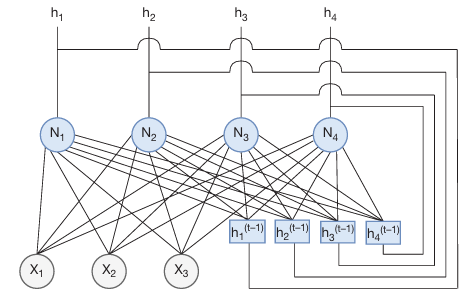 *Exemplo de uma arquitetura de uma RNN simples*

A figura acima mostra um vetor de entrada de três valores conectado a uma camada totalmente conectada de quatro neurônios. Os valores de *bias* foram omitidos da figura. Juntamente com as três entradas (e a entrada de *bias*), cada neurônio tem quatro entradas adicionais. Essas entradas recebem os valores de saída dos quatro neurônios, mas com um **atraso de um passo de tempo (timestep)**. Ou seja, no tempo t, ele receberá o valor de saída do tempo t-1. Denotamos essas saídas como h de hidden (oculto), porque as camadas recorrentes tipicamente servem como camadas ocultas dentro da rede.

O número de entradas para um neurônio em uma camada de RNN depende tanto do número de entradas para a camada (tipicamente determinado pelo número de neurônios na camada anterior) quanto do número de neurônios na própria camada.

## **REPRESENTAÇÃO MATEMÁTICA DE UMA CAMADA RECORRENTE**

Podemos representar uma camada recorrente usando matrizes. A forma como fica a representação lembra muito a representação matemática de uma camada *fully connected*. No entanto, o vetor de entrada para uma camada recorrente pode ser dividido em dois, o vetor de entrada real **Xt** e o vetor da saída anterior **Ht-1**. Da mesma forma, a matriz de pesos pode ser dividida em duas, uma para os pesos das entradas reais e outra para as conexões recorrentes. A fórmula pode ser representada como:

 *O b representa o vetor dos biases que são somados as somas ponderadas de cada um dos neurônios.*

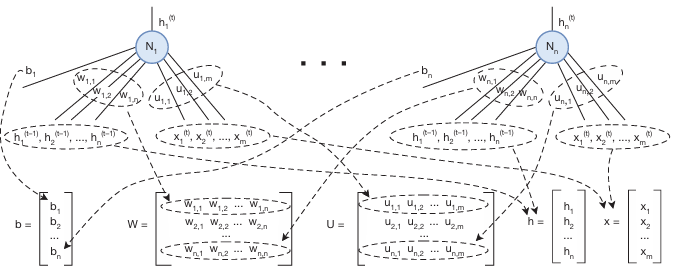 *Representação visual de como os elementos nas matrizes e vetores se mapeiam para entradas, conexçoes recorrentes, pesos e biases em uma camada recorrente.*

## **COMBINANDO CAMADAS EM UMA RNN**

Tentando criar uma rede para resolver o problema de previsão de vendas, montei uma arquitetura inicial básica para isso.

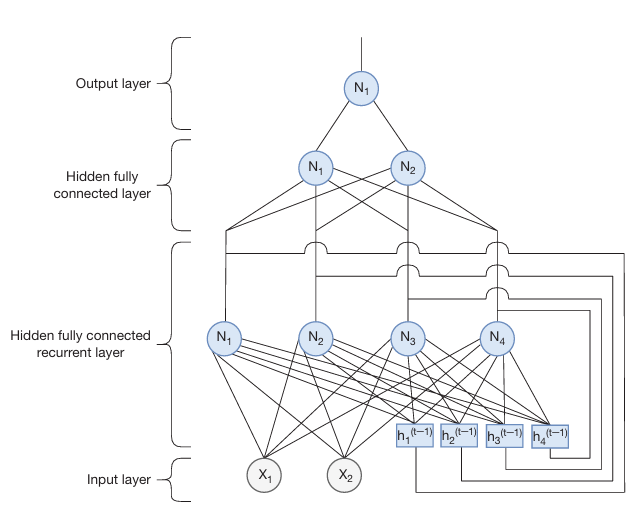 *Arquitetura montada para a previsão de vendas.*

Essa rede inicial possui duas entradas, representando as vendas históricas de livros e os gastos gerais do consumidor. Essas entradas alimentam uma camada recorrente com 4 neurônios, seguida por uma camada *fully connected* de 2 neurônios e uma camada de saída com um único neurônio. Com relação à funções de ativação, como queremos que a saída seja um valor numérico qualquer e não uma probabilidade, para a camada de saída usarei uma unidade linear simples. Para as *hidden layers*, posso escolher qualquer função de ativação não linear para camadas ocultas que comentei nos materiais passados.

O cálculo da saída desta rede é feito iterativamente, apresentando primeiro o vetor de entrada de um mês à rede e computando os estados ocultos, e depois apresentando o vetor de entrada do mês seguinte e computando novos estados ocultos, que são funções dos estados ocultos atuais e do novo vetor de entrada. Fazendo isso para todos os dados históricos a que tenho acesso e termino com uma previsão para o próximo mês. A rede pode usar todos esses dados e computar qualquer representação interna útil dos dados históricos que possa usar para prever o próximo mês. 

## **REPRESENTAÇÃO MAIS SIMPLES DA ARQUITETURA DE UMA RNN**

Até agora, desenhamos explicitamente todas as conexões em nossa *RNN*, o que não é prático à medida que avançamos para redes mais profundas com muitas unidades em cada camada. Para contornar essa limitação, uma maneira mais compacta de desenhar redes é deixar que um nó no grafo represente uma camada inteira, como na figura abaixo.

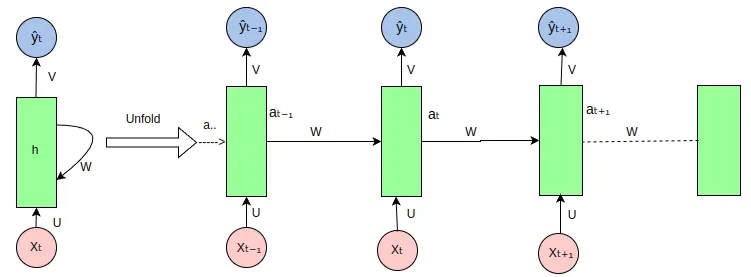 *Representação de uma RNN*

O retângulo representa a camada inteira e o círculo, neurônios individuais. Essas setas representam as conexões recorrentes. Com esta notação, muitas informações sobre a arquitetura ficam implícitas, então a figura precisa ser acompanhada por descrições textuais que deixem claro que ela é totalmente conectada, bem como o número de neurônios.

O lado direito da imagem mostra como fica uma camada recorrente **"desenrolada no tempo" (*unrolled intime*)**. Ao criar uma cópia da camada recorrente para cada passo de tempo, convertemos a camada recorrente em uma série de camadas *feedforward*. Isso significa que a camada recorrente é equivalente à rede *feedforward* se soubermos o comprimento da sequência de entrada? Não exatamente, porque uma distinção fundamental é descoberta se considerarmos os pesos da rede, que foram omitidos de todas as figuras. Na rede *feedforward*, podemos ter pesos diferentes para todas as conexões, mas na camada recorrente, os pesos precisam ser os mesmos para cada passo de tempo, por isso a representação desses pesos na imagem acima tem somente a letra **W** repetindo em todos os pesos de recorrência, a letra **U** repetindo como peso de entrada e a letra **V** repetindo como peso de saída. Ou seja, assim como as camadas convolucionais têm compartilhamento de pesos dentro de uma camada, as camadas recorrentes são como uma rede *feedforward* com compartilhamento de pesos entre camadas. Assim como o compartilhamento de pesos foi benéfico para as redes convolucionais, as redes recorrentes têm um benefício similar de exigir menos pesos para treinar.

Além de ajudar a compreender melhor a rede, essa representação ajuda a entender como o algoritmo de *backpropagation* funciona para essa rede.

## **BACKPROPAGATION NA RNN**

Uma vez que a rede é desenrolada, podemos retropropagar o erro exatamente da mesma forma que fazemos para uma rede feedforward, embora possa ser um tanto computacionalmente caro em casos com sequências de entrada longas. Assim como na camada convolucional, devemos garantir que o compartilhamento de pesos seja levado em conta ao atualizar os pesos. Em outras palavras, para cada peso, o algoritmo de *backpropagation* produzirá um valor de atualização para cada passo de tempo, mas quando quisermos atualizar o peso posteriormente, haverá apenas um peso a ser atualizado. Este algoritmo é conhecido como ***backpropagation* através do tempo (BPTT)**.

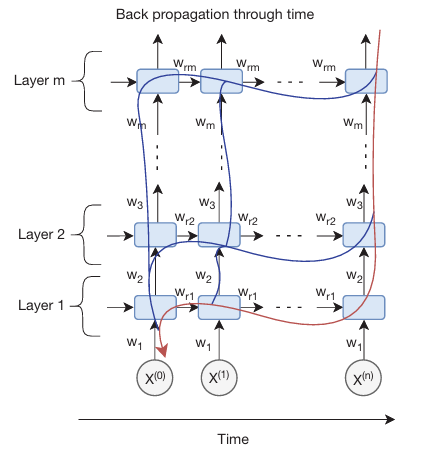 *Imagem que mostra o funcionamento desse algoritmo.*

A figura acima mostra uma *RNN* profunda com m camadas e n+1 passos de tempos.Além dos pesos normais que conectam as camadas (denotados como w1, w2, …, wm), existem também pesos recorrentes que conectam cada camada a si mesma (denotados como wr1, wr2, …,wrm). A figura também contém uma grade de setas ilustrando como o erro se propagará para trás para o algoritmo de aprendizado. O que é mostrado é o erro do nó de saída para o último passo de tempo, propagando-se para o peso de entrada para o primeiro passo de tempo, dividindo-se em múltiplos caminhos ao longo do percurso. Os caminhos verticais não são diferentes de uma rede feedforward regular. No entanto, agora também existem caminhos horizontais onde o erro se propaga para trás no tempo.

Em um material anterior, comentei sobre o problema do desaparecimento de gradientes (*vanishing gradients*), que era causado pela multiplicação do erro pela derivada da função de ativação (quando elas se aproximavam de 0) em cada camada da rede. As *RNNs* podem sofrer com isso, mas elas também sofrem com um problema diferente. Para simplificar, vamos considerar apenas a seta vermelha na figura acima. Vamos também imaginar que cada nó retangular é um único neurônio em vez de uma camada completa de neurônios. Finalmente, vamos supor que esses neurônios tenham funções de ativação lineares, de modo que suas derivadas sejam todas 1. Podemos agora calcular a derivada parcial em relação ao peso w1 usando a seguinte fórmula, onde os sobrescritos dentro de parênteses representam os passos de tempo:

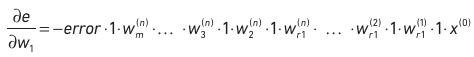

Dentro dessa fórmula, nota-se, devido ao compartilhamento de pesos, a propagação do erro para trás através das conexões recorrentes, ou seja, através do tempo , pode ser reescrita como *Wr1^n*, sendo n a representação da potência dos passos de tempo. O expoente n representa o número total de passos de tempo para um determinado exemplo de treinamento e pode ser grande. Por exemplo, um caso com três anos de dados, com um ponto de dado por dia, resultará em mais de 1.000 passos de tempo. Nesse sentido, se esse peso for um número menor que 1 e o multiplicar 1000 vezes, ele se aproximará de 0, ou seja, o **gradiente desaparece (*vanishing gradient*)**. Agora, caso esse peso seja maior que 1 e o multiplicar 1000 vezes, ele se aproximará do infinito, ou seja, o **gradiente explode (*exploding gradient*)**. 

Para simplificar o entendimento, este exemplo assumiu que cada nó na figura acima era um único neurônio e cada conexão recorrente consistia em um único peso. Na realidade, cada nó na figura representa uma camada recorrente inteira, que consiste em um grande número de neurônios. Em outras palavras, *wr1* na figura é uma matriz, porque cada camada tem múltiplos neurônios e cada neurônio tem um vetor de pesos. Isso, por sua vez, implica que, na realidade, a equação precedente é um pouco mais complexa e deveria ser declarada usando álgebra linear. Conceitualmente, a descrição ainda é a mesma, mas em vez de olhar para o valor de um único peso, precisamos considerar o autovalor da matriz de pesos. Se o autovalor for menor que 1, o gradiente corre o risco de desaparecer.

Resumidamente, isso do autovalor ocorre pois os autovalores nos dizem como a matriz "estica" ou "encolhe" o espaço em certas direções. Nesse sentido, se esse autovalor da matriz de pesos recorrentes for menor que 1, a cada multiplicação pela matriz durante a retropropagação, o gradiente é efetivamente "encolhido". Isso implica no *vanishing gradient*. Já para o caso do autovalor da matriz de pesos recorrente maior que 1, ocorre o efeito oposto. A cada multiplicação pela matriz de pesos durante a retropropagação, o gradiente é "esticado". Isso resulta no *exploding gradient*.

## **HANDS-ON: PREVENDO AS VENDAS DE LIVROS**

Nesse exemplo, usarei apenas uma variável de entrada (vendas históricas dos livros), mas também explicarei como fazer para mais variáveis. Cada linha do dataset contem ano/mês e um valor representando as vendas em milhões de dólares americanos. Ao contrário dos exemplos práticos anteriores, o modelo não pode consumir diretamente este formato, então o primeiro passo é organizar os dados adequadamente.

O exemplo de treinamento consiste em um vetor de comprimento arbitrário, onde cada entrada no vetor contém os dados de entrada para um único passo de tempo (*timestep*). Nesse exemplo, um passo de tempo é equivalente a um mês. Além do vetor de entrada, cada exemplo de treinamento consiste em um único valor de saída esperado. Ele representa as vendas de livros para o mês imediatamente seguinte ao mês mais recente no vetor de entrada. Este é o valor que queremos prever.

Tenho *X* meses de dados históricos e nota-se que posso criar pelo menos um exemplo de treinamento correspondente a cada mês. Por exemplo, o valor para o último mês pode resultar em um exemplo de treinamento onde os dados de entrada consistem em um vetor de comprimento (*X*-1). Da mesma forma, o segundo mês nos dados históricos pode resultar em um exemplo de treinamento onde os dados de entrada consistem em um vetor de comprimento 1, porque há apenas um único mês precedendo o segundo mês da temporada.

Decidi criar apenas um único exemplo de treinamento para cada mês e usar o máximo de histórico possível para cada exemplo. Decidi ainda que cada exemplo de treinamento deve ter pelo menos *MIN* meses de histórico. Acabaremos com (*X*-*MIN*) exemplos, onde o comprimento da entrada varia entre *MIN* e (*X*-1).

### Código de inicialização

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input, Flatten
import logging
tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 100
BATCH_SIZE = 16
TRAIN_TEST_SPLIT = 0.8 #80% treino, 20% teste
MIN = 12
FILE_PATH = r'C:\Users\João Pedro\Documents\LDL\data\bookstore-sales\book_stores_sales.csv'

def read_file(file_path):
    file = open(file_path, 'r', encoding='utf-8')
    next(file)  #Pular o cabeçalho
    data = []
    for line in file:
        values = line.split(',')
        data.append([float(values[1])])
    file.close()
    return np.array(data, dtype=np.float32)

#Carregar os dados e dividir em treino e teste
sales = read_file(FILE_PATH)
months = len(sales)
split = int(months * TRAIN_TEST_SPLIT)
train_sales = sales[0:split]
test_sales = sales[split:]

### Gráfico do histórico de vendas

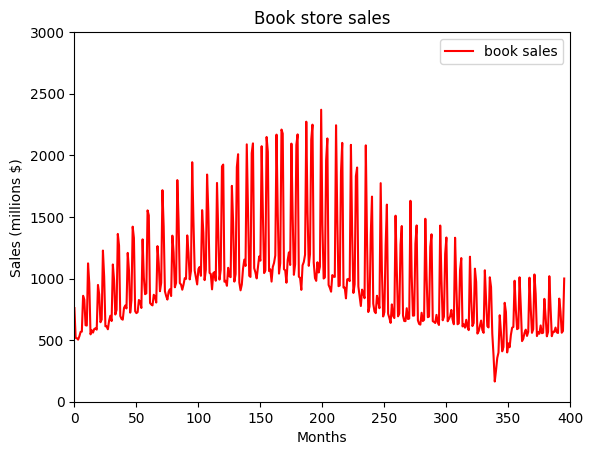

In [34]:
#Plotar os dados de vendas
x = range(len(sales))
plt.plot(x, sales, 'r-', label='book sales')
plt.title('Book store sales')
plt.axis([0, 400, 0.0, 3000.0])
plt.xlabel('Months')
plt.ylabel('Sales (millions $)')
plt.legend()
plt.show()

A partir do gráfico acima, fica claro que há um padrão sazonal e que a tendência geral nas vendas dos livros mudou ao longo do tempo, provavelmente devido ao aumento das vendas online. Os dados começam em 1992 e terminam em dezembro de 2024. A queda perto do mês 350 foi provavelmente causada pela pandemia de COVID-19 atingindo os Estados Unidos.

### Predição ingênua (*naïve prediction*)

Com a intenção de comparar se o modelo que vamos fazer agrega valor, criarei um modelo simples de comparação que prevê que as vendas do próximo mês serão iguais as vendas do mês atual.

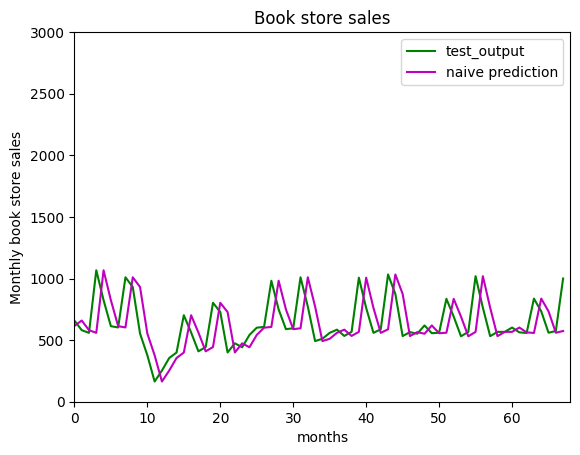

In [35]:
test_output = test_sales[MIN:]
naive_prediction = test_sales[MIN-1:-1]
x = range(len(test_output))
plt.plot(x, test_output, 'g-', label='test_output')
plt.plot(x, naive_prediction, 'm-', label='naive prediction')
plt.title('Book store sales')
plt.axis([0, len(test_output), 0.0, 3000.0])
plt.xlabel('months')
plt.ylabel('Monthly book store sales')
plt.legend()
plt.show()

### Padronizar os dados

In [50]:
#Padronizar os dados usando somente os dados de treino
mean = np.mean(train_sales)
stddev = np.mean(train_sales)
train_sales_std = (train_sales - mean)/stddev
test_sales_std = (test_sales - mean)/stddev

In [ ]:
#Criar os exemplos de treinamento
train_months = len(train_sales)
train_X = np.zeros((train_months-MIN, train_months-1, 1))
train_y = np.zeros((train_months-MIN, 1))
for i in range(0, train_months-MIN):
    train_X[i, -(i+MIN):, 0] = train_sales_std[0:i+MIN, 0]
    train_y[i, 0] = train_sales_std[i+MIN]

# #Criar os exemplos de teste
test_months = len(test_sales)
test_X = np.zeros((test_months-MIN, test_months-1, 1))
test_y = np.zeros((test_months-MIN, 1))
for i in range(0, test_months-MIN):
    test_X[i, -(i+MIN):, 0] = test_sales_std[0:i+MIN, 0]
    test_y[i, 0] = test_sales_std[i+MIN]

### Definindo a rede 

O modelo tem uma única camada recorrente de 128 neurônios e função de ativação *ReLU*. A segunda camada é uma *fully connected* com um neurônio e ativação linear, já que quero prever um valor numérico. Devido à função de ativação linear, usei *MSE* como função de *loss* e também, como métrica, utilizei o *MAE* (erro absoluto médio). O treinamento é de 100 *epochs* com *batch size* de 16.

In [ ]:
#Criando o modelo RNN
model = Sequential()
model.add(Input(shape=(None, 1))) #Instrui que o número de timesteps é variável
model.add(SimpleRNN(128, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])
model.summary()
history = model.fit(train_X, train_y, validation_data=(test_X, test_y), epochs=EPOCHS,
                    batch_size=BATCH_SIZE, verbose=2, shuffle=True) #Shuffle=True para embaralhar os dados de treino

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,769 (65.50 KB)

 Trainable params: 16,769 (65.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
19/19 - 1s - 63ms/step - loss: 0.1171 - mean_absolute_error: 0.2609 - val_loss: 0.0795 - val_mean_absolute_error: 0.2599
Epoch 2/100
19/19 - 0s - 22ms/step - loss: 0.0683 - mean_absolute_error: 0.1981 - val_loss: 0.0395 - val_mean_absolute_error: 0.1712
Epoch 3/100
19/19 - 0s - 23ms/step - loss: 0.0405 - mean_absolute_error: 0.1574 - val_loss: 0.0395 - val_mean_absolute_error: 0.1789
Epoch 4/100
19/19 - 1s - 36ms/step - loss: 0.0183 - mean_absolute_error: 0.1042 - val_loss: 0.0144 - val_mean_absolute_error: 0.0856
Epoch 5/100
19/19 - 1s - 47ms/step - loss: 0.0101 - mean_absolute_error: 0.0780 - val_loss: 0.0172 - val_mean_absolute_error: 0.1039
Epoch 6/100
19/19 - 1s - 40ms/step - loss: 0.0080 - mean_absolute_error: 0.0673 - val_loss: 0.0135 - val_mean_absolute_error: 0.0915
Epoch 7/100
19/19 - 1s - 45ms/step - loss: 0.0085 - mean_absolute_error: 0.0689 - val_loss: 0.0095 - val_mean_absolute_error: 0.0744
Epoch 8/100
19/19 - 1s - 47ms/step - loss: 0.0056 - mean_absolute_err

Após o treinamento de 100 *epochs*, cheguei a uma *loss* de 0,0015 para treino e 0,0061 para teste e um *MAE* de 0,0295 para o treino e 0,058 para teste. 

Uma questão fundamental é se este resultado é bom ou ruim. Felizmente, defini um modelo ingênuo que posso usar como ponto de comparação. Quando defini o modelo ingênuo, fiz isso com os dados não padronizados, enquanto o EQM e o EAM do Keras são calculados a partir dos dados padronizados. Assim, criarei uma nova versão das previsões ingênuas com base em dados padronizados.

### Computando *loss* e métrica para o modelo ingênuo

In [42]:
#Calcular a loss e métrica para o modelo ingênuo, depois de padronizar os dados
test_output = test_sales_std[MIN:]
naive_prediction = test_sales_std[MIN-1:-1]
mean_squared_error = np.mean(np.square(naive_prediction 
                                    - test_output))
mean_abs_error = np.mean(np.abs(naive_prediction 
                            - test_output))
print('MSE de teste do modelo ingênuo: ', mean_squared_error)
print('MAE de teste do modelo ingênuo: ', mean_abs_error)

MSE de teste do modelo ingênuo:  0.03897251
MAE de teste do modelo ingênuo:  0.14738454


*MSE* de 0,039 e *MAE* de 0,147 comparados ao *MSE* de 0,0061 e *MAE* de 0,058 para o teste da *RNN* mostra que o trabalho do nosso modelo é bem superior ao de um modelo ingênuo.

### Utilizando o modelo treinado

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


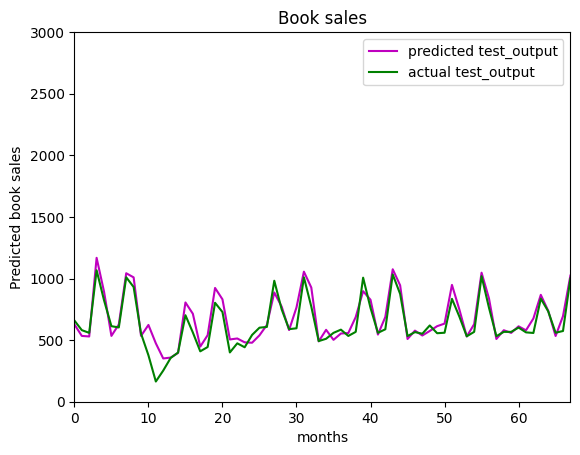

In [48]:
#Usando o modelo treinado para prever os dados de teste
predicted_test = model.predict(test_X, len(test_X))
predicted_test = np.reshape(predicted_test,
                        (len(predicted_test)))
predicted_test = predicted_test * stddev + mean #Despadronizar os dados previstos

#Plotar os resultados
x = range(len(test_sales)-MIN)
plt.plot(x, predicted_test, 'm-',
        label='predicted test_output')
plt.plot(x, test_sales[-(len(test_sales)-MIN):], 
'g-', label='actual test_output')
plt.title('Book sales')
plt.axis([0, 67, 0.0, 3000.0])
plt.xlabel('months')
plt.ylabel('Predicted book sales')
plt.legend()
plt.show()

A partir desse gráfico, nota-se que as previsões feitas pelo modelo fazem muito sentido.

### Comparação a uma rede sem recorrência

Outra comparação relevante é compará-la a um modelo de rede mais simples para ver se nos beneficiamos da complexidade adicionada ao modelo. Em particular, seria interessante entender se a capacidade de analisar sequências de entrada longas é benéfica, comparando com uma rede *feedforward* regular apresentada com um histórico limitado.

In [53]:
# Reduce lookback period in input.
train_X = train_X[:, (train_months - 13):, :]
test_X = test_X[:, (test_months - 13):, :]

#Create feedforward model.

#Criando o modelo RNN
model = Sequential()
model.add(Input(shape=(12, 1))) #Instrui que o número de timesteps é variável
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])
model.summary()
history = model.fit(train_X, train_y, validation_data=(test_X, test_y), epochs=EPOCHS,
                    batch_size=BATCH_SIZE, verbose=2, shuffle=True) #Shuffle=True para embaralhar os dados de treino

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
19/19 - 1s - 33ms/step - loss: 0.0702 - mean_absolute_error: 0.1931 - val_loss: 0.0164 - val_mean_absolute_error: 0.0918
Epoch 2/100
19/19 - 0s - 5ms/step - loss: 0.0169 - mean_absolute_error: 0.1026 - val_loss: 0.0126 - val_mean_absolute_error: 0.0859
Epoch 3/100
19/19 - 0s - 5ms/step - loss: 0.0071 - mean_absolute_error: 0.0652 - val_loss: 0.0127 - val_mean_absolute_error: 0.0844
Epoch 4/100
19/19 - 0s - 5ms/step - loss: 0.0056 - mean_absolute_error: 0.0570 - val_loss: 0.0129 - val_mean_absolute_error: 0.0841
Epoch 5/100
19/19 - 0s - 5ms/step - loss: 0.0050 - mean_absolute_error: 0.0532 - val_loss: 0.0130 - val_mean_absolute_error: 0.0852
Epoch 6/100
19/19 - 0s - 5ms/step - loss: 0.0046 - mean_absolute_error: 0.0507 - val_loss: 0.0135 - val_mean_absolute_error: 0.0870
Epoch 7/100
19/19 - 0s - 5ms/step - loss: 0.0044 - mean_absolute_error: 0.0508 - val_loss: 0.0126 - val_mean_absolute_error: 0.0839
Epoch 8/100
19/19 - 0s - 5ms/step - loss: 0.0044 - mean_absolute_error: 0.0

A *loss* da *feedforward* acabou sendo 0,0018 para treino e para teste 0,0082. O erro de treino foi 20% maior e o de teste foi quase 35% maior que o da RNN. Logo, as adições que fizemos ficaram mais complexas, teoricamente falando, mas o resultado foi melhor.

### Mudanças no código para trabalhar com mais de uma variável

*OBS: Esse trecho de código assume que essas outras variáveis a serem adicionadas já estão padronizadas.*

In [ ]:
#Criando exemplos de treinamento com mais de uma variável
train_months = len(train_sales)
train_X = np.zeros((train_months-MIN, train_months-1, 2))
train_y = np.zeros((train_months-MIN, 1))
for i in range(0, train_months-MIN):
    train_X[i, -(i+MIN):, 0] = train_sales_std[0:i+MIN]
    train_X[i, -(i+MIN):, 1] = train_sales_std2[0:i+MIN] #Ponto de mudança
    train_y[i, 0] = train_sales_std[i+MIN]

#Criando exemplos de teste.
test_months = len(test_sales)
test_X = np.zeros((test_months-MIN, test_months-1, 2))
test_y = np.zeros((test_months-MIN, 1))
for i in range(0, test_months-MIN):
    test_X[i, -(i+MIN):, 0] = test_sales_std[0:i+MIN]
    test_X[i, -(i+MIN):, 1] = test_sales_std2[0:i+MIN] #Ponto de mudança
    test_y[i, 0] = test_sales_std[i+MIN]
    
#Resto do código
model.add(SimpleRNN(128, activation='relu',
                input_shape=(None, 2))) #No lugar do dois vai a quantidade de variáveis que você quer usar